In [1]:
library(nlme)

ratpup           <- read.table('rat_pup.dat', header=TRUE)
ratpup$sex       <- as.factor(ratpup$sex)
ratpup$litter    <- as.factor(ratpup$litter)
ratpup$treatment <- as.factor(ratpup$treatment)

# Implementing the Model in `R`
As a final part of this lesson, we will see the process of fitting the model we have developed for the `ratpup` dataset using the `lme()` function. Despite the time spent building and considering this model, we will see that the specification and fitting process is deceptively quick. In a way, this belies the complexity and thought that sits behind the model which is why the temptation is often to skip this process, especially when introducing these methods to students. However, skipping these steps can lead to confusion, conceptual misunderstanding and knowledge gaps. This is the reason why we have spent so long building to this point.

## Collapsing to Mixed-effects Form
As we know, in order to fit a multilevel model using `lme()`, we need to collapse over the levels and specify the model in mixed-effects form. Our current two-level model is given below, where you can flip between the generic notation and the labels for this dataset using the tabs.

````{tab-set}
```{tab-item} Generic Notation
$$
\begin{alignat*}{1}
    \text{Level 1} \\
    y^{(k)}_{ij}     &= \mu^{(k)} + \alpha^{(k)}_{j} + \eta^{(k)}_{ij}  \\
    \quad \\
    \text{Level 2} \\
    \mu^{(k)}        &= \mu + \beta_{l} + \xi^{(k)}  \\
    \alpha^{(k)}_{j} &= \alpha_{j} + (\alpha\beta)_{jl} + \phi^{(k)}_{j}
\end{alignat*}
$$
```

```{tab-item} Data Labels
$$
\begin{alignat*}{1}
    \text{Level 1} \\
    \text{weight}^{(k)}_{ij}     &= \text{mean}^{(k)} + \text{sex}^{(k)}_{j} + \eta^{(k)}_{ij}  \\
    \quad \\
    \text{Level 2} \\
    \text{mean}^{(k)}    &= \text{mean} + \text{treatment}_{l} + \xi^{(k)}  \\
    \text{sex}^{(k)}_{j} &= \text{sex}_{j} + (\text{sex} \times \text{treatment})_{jl} + \phi^{(k)}_{j}
\end{alignat*}
$$
```
````

In order to turn this into a single-level mixed-effects models, we simply replace the terms at Level 1 with their equalities at Level 2. This is shown below

````{tab-set}
```{tab-item} Generic Notation
$$
y^{(k)}_{ij} = \overbrace{\mu + \beta_{l} + \xi^{(k)}}^{\mu^{(k)}} + \overbrace{\alpha_{j} + (\alpha\beta)_{jl} + \phi^{(k)}_{j}}^{\alpha^{(k)}_{j}} + \eta^{(k)}_{ij}
$$
```

```{tab-item} Data Labels
$$
\text{weight}^{(k)}_{ij} = \overbrace{\text{mean} + \text{treatment}_{l} + \xi^{(k)}}^{\text{mean}^{(k)}} + \overbrace{\text{sex}_{j} + (\text{sex} \times \text{treatment})_{jl} + \phi^{(k)}_{j}}^{\text{sex}^{(k)}_{j}} + \eta^{(k)}_{ij}
$$
```
````

Finally, we collect like-terms together such that the *fixed* elements are together and the *random* elements together. This is not strictly necessary, but makes the model easier to understand.

````{tab-set}
```{tab-item} Generic Notation
$$
y^{(k)}_{ij} = \overbrace{\mu + \alpha_{j} + \beta_{l} + (\alpha\beta)_{jl}}^{\text{fixed-effects}} + \overbrace{\xi^{(k)} + \phi^{(k)}_{j} + \eta^{(k)}_{ij}}^{\text{random-effects}}
$$
```

```{tab-item} Data Labels
$$
\text{weight}^{(k)}_{ij} = \overbrace{\text{mean} + \text{sex}_{j} + \text{treatment}_{l} + (\text{sex} \times \text{treatment})_{jl}}^{\text{fixed-effects}} + \overbrace{\xi^{(k)} + \phi^{(k)}_{j} + \eta^{(k)}_{ij}}^{\text{random-effects}}
$$
```
````


## Specifying the Random-effects
Given the mixed-effects form above, we need to think about how we express the random-effects to `lme()`. The fixed effects are easy, because this will just be `weight ~ 1 + sex + treatment + sex:treatment`. So, no different to what we have seen previously and effectively what we can see written above. However, the random-effects are currently written as

$$
\xi^{(k)} + \phi^{(k)}_{j} + \eta^{(k)}_{ij},
$$

which need a moments thought in order to turn them into something `lme()` can use.

To begin with, no matter what we specify there will always be a final error term. This is the same as any regression model. We never tell `lm()` of `gls()` that we want errors because they are a fundamental component of the model. So, we do not need to worry about the final error term $\eta^{(k)}_{ij}$. So, all we really need to tell `lme()` about is

$$
\xi^{(k)} + \phi^{(k)}_{j}.
$$

Now, notice that both of these terms relate to a specific litter $k$, so another way of writing them would be *conditional* on the value of $k$

$$
\xi + \phi_{j} | k.
$$

Now that we have moved $(k)$ out of the way, it starts to become clearer what these terms mean within a single litter. For a given litter $k$, we have a *constant value* called $\xi$ and an *effect of sex* $j$ called $\phi$. If we were to write this as an `R` formula for a single litter it would be

`1 + sex`

and to make this conditional on each litter, we use

`1 + sex | litter`

which can be read as a *random intercept and random slope of sex per-litter*. This is exactly what we give to `lme()`.

## Implementation Using `lme()`
Taking everything together, we can specify this model using `lme()`. In the code below, we choose to make the fixed-effects explicit by using the `fixed=` argument. This is not strictly necessary and can be omitted in future, but hopefully it makes the function call as clear as possible.

In [2]:
library(nlme)

lme.ratpup.1 <- lme(fixed  = weight ~ treatment + sex + sex:treatment, # fixed-effects 
                    random =        ~ 1 + sex|litter,                  # random-effects
                    data   = ratpup)                                   

summary(lme.ratpup.1)

Linear mixed-effects model fit by REML
  Data: ratpup 
      AIC      BIC    logLik
  438.799 476.3564 -209.3995

Random effects:
 Formula: ~1 + sex | litter
 Structure: General positive-definite, Log-Cholesky parametrization
            StdDev    Corr  
(Intercept) 0.5019186 (Intr)
sexMale     0.1554335 0.888 
Residual    0.4005464       

Fixed effects:  weight ~ treatment + sex + sex:treatment 
                          Value Std.Error  DF  t-value p-value
(Intercept)            6.200295 0.1685193 292 36.79278  0.0000
treatmentHigh         -0.293458 0.2647520  24 -1.10843  0.2787
treatmentLow          -0.315255 0.2376438  24 -1.32658  0.1971
sexMale                0.441064 0.0878297 292  5.02181  0.0000
treatmentHigh:sexMale -0.083920 0.1529263 292 -0.54876  0.5836
treatmentLow:sexMale  -0.077938 0.1272381 292 -0.61253  0.5407
 Correlation: 
                      (Intr) trtmnH trtmnL sexMal trtH:M
treatmentHigh         -0.637                            
treatmentLow          -0.709 

In [3]:
random.effects(lme.ratpup.1)

    (Intercept)      sexMale
1   0.283091048  0.066250415
2  -0.153500107 -0.033344540
3   0.701543759  0.178278121
4  -0.135362756 -0.031915416
5   0.340037227  0.105202850
6   0.390393255  0.169711123
7  -0.158110148 -0.063206359
8  -0.440380383 -0.124903334
9  -0.935772451 -0.277784567
10  0.108060557  0.011711707
11 -0.319291431 -0.089044095
12  1.080803194  0.297293631
13 -0.268172395 -0.079082057
14 -0.234212253 -0.069014833
15 -0.004590989 -0.009742578
16  0.030052979 -0.004193467
17 -0.521318592 -0.150524666
18  0.183390270  0.088278074
19  0.110812589  0.022647114
20 -0.057473372 -0.006617124
21 -0.749232516 -0.202209691
22 -0.566187590 -0.160408742
23  0.942642618  0.266500217
24 -0.131482487 -0.035557072
25  0.345791183  0.093074636
26  0.273784479  0.073033835
27 -0.115315687 -0.034433183

Recall from earlier that litter 12 had *no* male pups. Despite this, there is still a random slope of `sex` for this litter. How is this possible? This is the process of *pooling* in action. 

## Visualising the Model

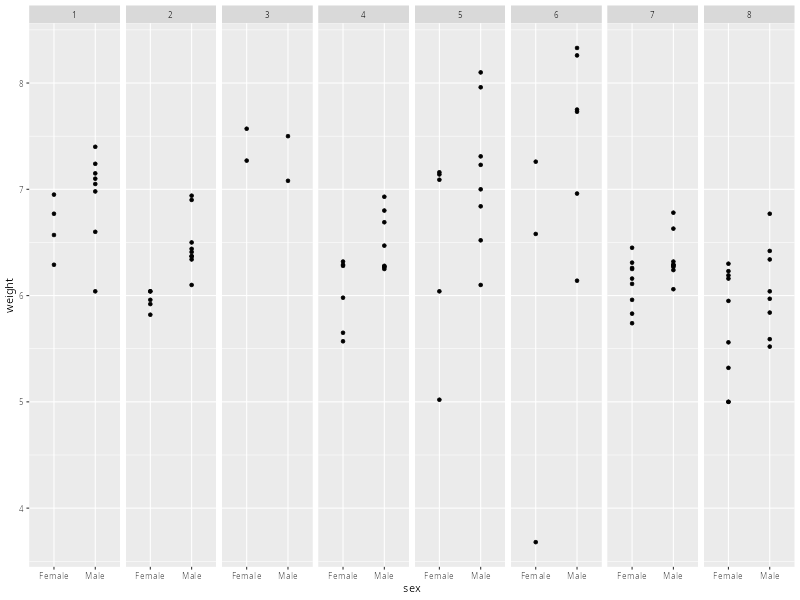

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

In [4]:
library(ggplot2)

litters.to.plot <- as.character(seq(1,8))                       # select litters to plot
ratpup.plot     <- ratpup[ratpup$litter %in% litters.to.plot, ] # subset rows by litter labels

ggplot(ratpup.plot, aes(x=sex, y=weight)) +
  geom_point() +
  geom_smooth() +
  facet_grid(~litter)

## The Marginal Covariance Structure

           1         2         3         4         5         6         7
1  0.5751104 0.4146730 0.4146730 0.4146730 0.4146730 0.4146730 0.4146730
2  0.4146730 0.5751104 0.4146730 0.4146730 0.4146730 0.4146730 0.4146730
3  0.4146730 0.4146730 0.5751104 0.4146730 0.4146730 0.4146730 0.4146730
4  0.4146730 0.4146730 0.4146730 0.5751104 0.4146730 0.4146730 0.4146730
5  0.4146730 0.4146730 0.4146730 0.4146730 0.5751104 0.4146730 0.4146730
6  0.4146730 0.4146730 0.4146730 0.4146730 0.4146730 0.5751104 0.4146730
7  0.4146730 0.4146730 0.4146730 0.4146730 0.4146730 0.4146730 0.5751104
8  0.4146730 0.4146730 0.4146730 0.4146730 0.4146730 0.4146730 0.4146730
9  0.3212178 0.3212178 0.3212178 0.3212178 0.3212178 0.3212178 0.3212178
10 0.3212178 0.3212178 0.3212178 0.3212178 0.3212178 0.3212178 0.3212178
11 0.3212178 0.3212178 0.3212178 0.3212178 0.3212178 0.3212178 0.3212178
12 0.3212178 0.3212178 0.3212178 0.3212178 0.3212178 0.3212178 0.3212178
           8         9        10        11        1

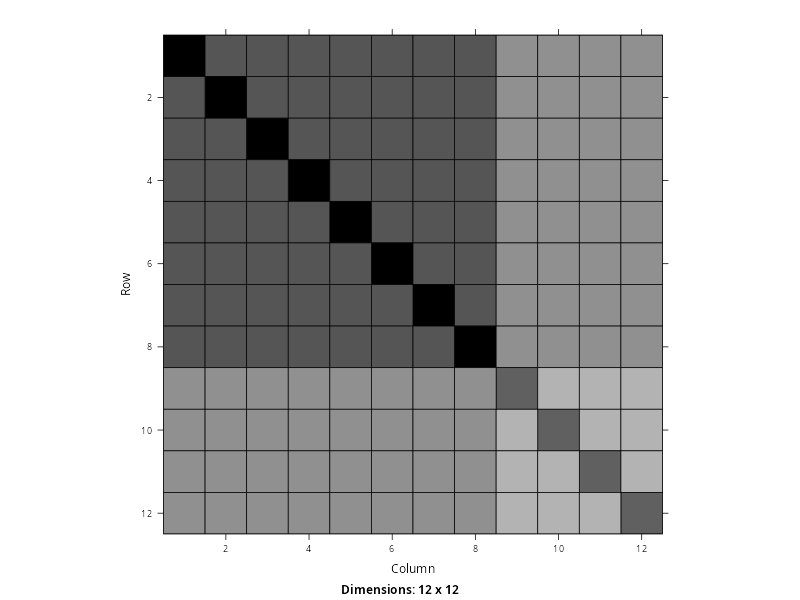

In [5]:
library('Matrix')
Sigma <- getVarCov(lme.ratpup.1, type="marginal", individual="1")$`1` # Litter 1
print(Sigma)
Matrix::image(as(Sigma,'Matrix'))

In [6]:
library('Matrix')

fullVarCov <- function(fit) {
  grouping_var_name <- names(fit$groups)[1] # get grouping variable name (e.g "id")
  groups <- fit$data[[grouping_var_name]]   # use name to get grouping variable
  groups <- unique(as.character(groups))    # reduce grouping variable to unique values

  # for each unique grouping variable value, extract the covariance matrices
  blocks <- lapply(groups, function(gi) {
    S <- getVarCov(fit, individual = gi, type = "marginal")
    if (is.list(S)) {
      S <- S[[gi]]
    }
    as.matrix(S)
  })

  # put the covariance matrices into blocks
  V <- bdiag(blocks)
  V
}

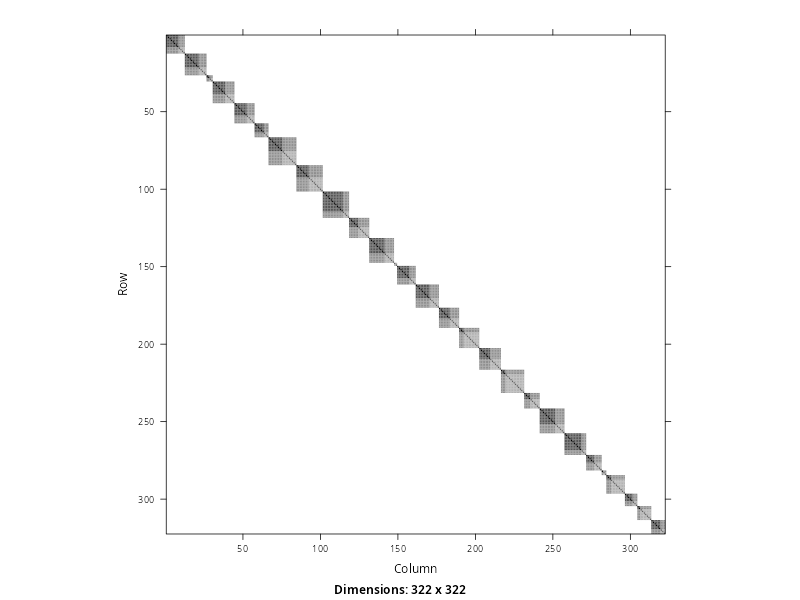

In [7]:
Sigma.Big <- fullVarCov(lme.ratpup.1)
image(Sigma.Big)

Here we can see how the size of each litter corresponds to the dimensions of its covariance block. For instance, litter 3 is very small whereas litter 7 is quite large. Within each covariance block, we can also see the patterns that correspond to the male pups, the female pups and the correlation between them. In addition, notice that the covariance structure is 0 between litters. This is why we considered litter to be the "boundary of dependency". Everything *within* a litter is correlated, everything *between* litters is independent. In effect, `litter` is being treated the same way that `subject` would be treated under repeated measurements.

## Should `sex` be Fixed or Random?

In [8]:
lme.mod.0 <- lme(weight ~ treatment + sex + sex:treatment, random= ~       1|litter, data=ratpup, method='ML', control=lmeControl(opt='optim'))
lme.mod.1 <- lme(weight ~ treatment + sex + sex:treatment, random= ~ 1 + sex|litter, data=ratpup, method='ML', control=lmeControl(opt='optim')) 

anova(lme.mod.0,lme.mod.1)

          Model df      AIC      BIC    logLik   Test  L.Ratio p-value
lme.mod.0     1  8 425.9672 456.1636 -204.9836                        
lme.mod.1     2 10 425.2734 463.0189 -202.6367 1 vs 2 4.693801  0.0957

[^sextextbook-foot]: It is interesting to note that, in their description of this analysis, [West, Welch & Galecki (2022)](https://www.taylorfrancis.com/books/mono/10.1201/9781003181064/linear-mixed-models-brady-west-kathleen-welch-andrzej-galecki?context=ubx&refId=4dbda113-7f59-4ba9-a710-897ef536cfee) make the decision to fix `sex` to a constant across litters, under the belief that there is a universal effect of `sex` on weight that is not influenced by individual litters.